# What the well median hides

A well median summarizes a population that is rarely uniform. If a fifth of the cells respond strongly and the rest
do not, the median reports a mild effect, and the fact that there are two populations is lost before analysis
starts.

This page works on the 13,578 cells of {func}`~mantispy.ds.jump_cells`, 24 wells of the JUMP plate `BR00121438`,
to ask what the median misses.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

import mantispy as mt

raw = mt.ds.jump_cells()
cells = raw.copy()
mt.pp.normalize(cells, by="Metadata_Plate", reference="negcon")

/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_86471/4066881822.py:10: UserWarning: 285 of 5839 features have no spread in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon'. Adding epsilon=1e-18 to their scale multiplies them by up to 1e18, so they dominate every distance downstream. They are flagged in var['degenerate_scale'], and pp.feature_select drops them by default; to drop them now, adata = adata[:, ~adata.var['degenerate_scale']].copy(). A variance or outlier cut does not catch a feature that varies across a plate but is constant among its control wells; the flag does.
  mt.pp.normalize(cells, by="Metadata_Plate", reference="negcon")


At this resolution a feature that barely varies among the control cells can come back enormous from normalization
without being flagged as degenerate, so `drop_outliers` joins the default selection.

In [2]:
mt.pp.feature_select(
    cells,
    operations=(
        "drop_degenerate",
        "variance_threshold",
        "correlation_threshold",
        "drop_na_columns",
        "blocklist",
        "drop_outliers",
    ),
    na_cutoff=0.0,
)
cells = mt.pp.subset_features(cells)
sc.pp.pca(cells, n_comps=20)
cells

AnnData object with n_obs × n_vars = 13578 × 1564
    obs: 'Metadata_ImageNumber', 'Metadata_ObjectNumber', 'Metadata_AbsPositionZ', 'Metadata_AbsTime', 'Metadata_BinningX', 'Metadata_BinningY', 'Metadata_ChannelID', 'Metadata_ChannelName', 'Metadata_Col', 'Metadata_ExposureTime', 'Metadata_FieldID', 'Metadata_ImageResolutionX', 'Metadata_ImageResolutionY', 'Metadata_ImageSizeX', 'Metadata_ImageSizeY', 'Metadata_MainEmissionWavelength', 'Metadata_MainExcitationWavelength', 'Metadata_MaxIntensity', 'Metadata_ObjectiveMagnification', 'Metadata_ObjectiveNA', 'Metadata_PlaneID', 'Metadata_Plate', 'Metadata_PositionX', 'Metadata_PositionY', 'Metadata_PositionZ', 'Metadata_Row', 'Metadata_Site', 'Metadata_Well', 'Metadata_Center_X', 'Metadata_Center_Y', 'Metadata_Source', 'Metadata_JCP2022', 'Metadata_InChIKey', 'Metadata_Perturbation', 'Metadata_Control'
    var: 'object', 'feature_group', 'feature', 'channel', 'scale', 'angle', 'gray_levels', 'radial_bin', 'params', 'is_feature', 'selected

## The typical cell, or some cells?

`method="mahalanobis"` asks whether the group's typical cell is far from the controls. `method="ks"` compares the
whole distribution of cell distances against the controls', so it answers a different question: whether *some*
cells moved, even when the middle of the distribution did not.

In [3]:
for method in ("mahalanobis", "ks"):
    mt.tl.hit_calling(
        cells,
        groupby="Metadata_Perturbation",
        reference="negcon",
        use_rep="X_pca",
        method=method,
        n_permutations=500,
        key_added=method,
    )

comparison = pd.DataFrame(
    {
        "median distance": cells.uns["mantispy"]["mahalanobis"].set_index("group")["distance"],
        "KS statistic": cells.uns["mantispy"]["ks"].set_index("group")["distance"],
    }
)
comparison.sort_values("KS statistic", ascending=False).head(8)

,median distance,KS statistic
group,,
JCP2022_098688,6.399190,0.541206
JCP2022_010404,4.354676,0.449715
JCP2022_115963,4.679109,0.427783
JCP2022_116560,4.447202,0.421797
JCP2022_067432,4.427565,0.401069
JCP2022_079715,3.769805,0.244919
JCP2022_035095,3.660268,0.235385
JCP2022_061421,3.469361,0.205156


One caution applies to every cell-level test on this page. Cells from one well share its plate position, its
seeding density and its focus, so they are not independent draws; the unit the experiment randomized is the well.
A null that shuffles cells assumes more evidence than the design supports, and p-values come out small for reasons
that have nothing to do with the treatment. Read a cell-level call as a ranking, and put the well-level call beside
it before believing it.

## What the median misses

Each cell's own distance from the control centroid is on `obs`. For each compound, how far its typical cell moved,
and what share of its cells sit beyond the distance that only one control cell in twenty reaches:

In [4]:
distance = cells.obs["mahalanobis_row_distance"].astype(float)
cutoff = distance[cells.obs["Metadata_Control"].to_numpy()].quantile(0.95)
group = cells.obs["Metadata_Perturbation"]
spread = pd.DataFrame(
    {
        "median distance": distance.groupby(group, observed=True).median(),
        "share beyond the controls' 95th percentile": (distance > cutoff).groupby(group, observed=True).mean(),
    }
)
spread.sort_values("share beyond the controls' 95th percentile", ascending=False).round(2)

,median distance,share beyond the controls' 95th percentile
Metadata_Perturbation,,
JCP2022_098688,6.40,0.37
JCP2022_115963,4.68,0.19
JCP2022_067432,4.43,0.16
JCP2022_010404,4.35,0.15
JCP2022_116560,4.45,0.15
JCP2022_035095,3.66,0.12
JCP2022_079715,3.77,0.11
JCP2022_001890,3.47,0.10
JCP2022_050797,3.13,0.07


The DMSO wells, JCP2022_033924, sit at 5% by construction. The compound whose typical cell moved furthest, JCP2022_098688, has 37% of
its cells beyond the controls' 95th percentile, and the next four have 15 to 19%. Even the strongest response on
this plate leaves most of a well's cells where the controls are, and a well median summarizes a minority that
moved together with a majority that did not.

## A change in shape

The same idea applies feature by feature. {func}`~mantispy.tl.effect_size` compares locations;
{func}`~mantispy.tl.wasserstein_features` compares whole distributions, so it sees a treatment that widens a
feature without moving its centre.

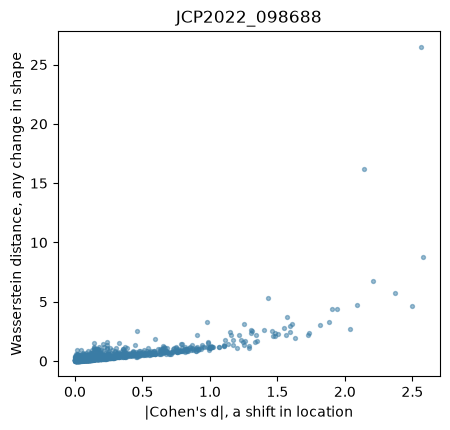

In [5]:
mt.tl.effect_size(cells, groupby="Metadata_Perturbation", reference="negcon")
mt.tl.wasserstein_features(cells, groupby="Metadata_Perturbation", reference="negcon")

treated = comparison["KS statistic"].drop(index="JCP2022_033924").idxmax()
effect = cells.uns["mantispy"]["effect"]
shift = cells.uns["mantispy"]["wasserstein"]
paired = pd.DataFrame(
    {
        "location": effect.loc[effect["group"] == treated].set_index("feature")["effect"].abs(),
        "shape": shift.loc[shift["group"] == treated].set_index("feature")["distance"],
    }
).dropna()

fig, ax = plt.subplots(figsize=(4.6, 4.4))
ax.scatter(paired["location"], paired["shape"], s=8, alpha=0.5, color="#3a7ca5")
ax.set(xlabel="|Cohen's d|, a shift in location", ylabel="Wasserstein distance, any change in shape", title=treated)
fig.tight_layout()

Most features lie on one rising curve, where the shift in location accounts for the distance. A few sit well
above it: their distributions changed shape by more than the shift of their centre explains, which a test on means
alone does not report.

## Working at this scale

A whole screen has a million cells by four thousand features, which is 16 GB of float32 before
any transform allocates its output. `pp.downsample` caps the number of cells per group (by
default per well), so the densest wells do not dominate, and `stratify` keeps rare
perturbations represented.

Explore on a sample, then confirm on the full data.

In [6]:
small = mt.pp.downsample(cells, n_per_group=100)
{
    "before": (cells.n_obs, cells.n_vars),
    "after": (small.n_obs, small.n_vars),
    "megabytes": (round(cells.n_obs * cells.n_vars * 4 / 1e6, 1), round(small.n_obs * small.n_vars * 4 / 1e6, 1)),
    "wells still represented": int(small.obs.groupby(["Metadata_Plate", "Metadata_Well"], observed=True).ngroups),
}

{'before': (13578, 1564),
 'after': (2400, 1564),
 'megabytes': (84.9, 15.0),
 'wells still represented': 24}

## Cell states, and what changed about them

Clustering uses scanpy. `tl.cluster_composition` then turns the cluster labels into an object whose rows are
wells, whose columns are cell states, and whose values are the fraction of that well's cells in each state. It is
an ordinary mantispy object, so `tl.map`, `pp.normalize` and the plotting functions work on cell-state composition
as they do on features.

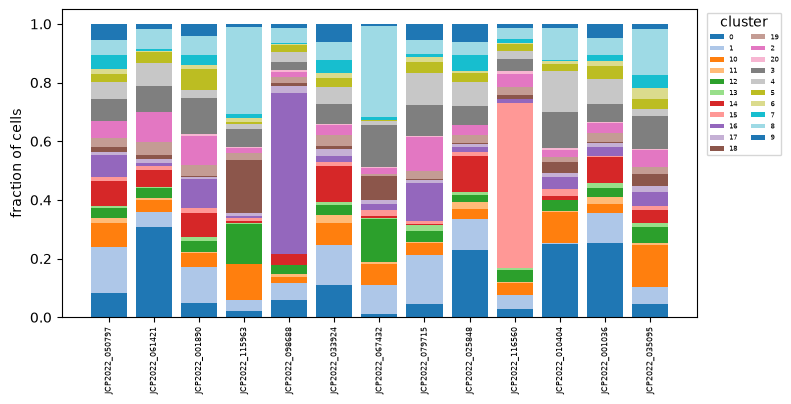

In [7]:
sc.pp.neighbors(cells)
sc.tl.leiden(cells, key_added="leiden", flavor="igraph", n_iterations=2)

composition = mt.tl.cluster_composition(cells)
ax = mt.pl.cluster_composition(composition)
plt.show()

In [8]:
by_group = pd.DataFrame(np.asarray(composition.X), columns=list(composition.var_names))
by_group = by_group.groupby(composition.obs["Metadata_Perturbation"].astype(str).to_numpy()).mean()
control = str(cells.obs.loc[cells.obs["Metadata_Control"].to_numpy(), "Metadata_Perturbation"].iloc[0])
shift = by_group - by_group.loc[control]
largest = shift.stack().abs().nlargest(5).index
pd.DataFrame(
    [
        {
            "compound": compound,
            "cluster": state,
            "fraction": by_group.loc[compound, state],
            "DMSO": by_group.loc[control, state],
        }
        for compound, state in largest
    ]
).round(3)

,compound,cluster,fraction,DMSO
0,JCP2022_116560,15,0.563,0.016
1,JCP2022_098688,16,0.548,0.021
2,JCP2022_067432,8,0.309,0.063
3,JCP2022_115963,8,0.295,0.063
4,JCP2022_061421,0,0.308,0.111


Two compounds put more than half of their cells into one state: JCP2022_116560 into cluster 15 and
JCP2022_098688 into cluster 16, each of which holds about 2% of the DMSO cells. Clustering always returns clusters,
21 here, most of them shared by every compound. What distinguishes a cell state from a partition of the data is whether
the composition differs between conditions, which is what this object measures.

## Two different questions

`cluster_composition` asks whether the mix of cell states changed. `tl.subpopulation_hits` asks whether, within a
state that treated and control cells share, the treated cells differ from the controls: a shift small enough that
the cells stay in their states. The statistic is a KS test on each cell's distance to the control center of its own
cluster, so each cell is compared with controls in the same state.

In [9]:
mt.tl.subpopulation_hits(cells, use_rep="X_pca")
table = cells.uns["mantispy"]["subpopulation_hits"]
{
    "tests": len(table),
    "significant": int((table["qvalue"] < 0.05).sum()),
    "significant per compound": table.loc[table["qvalue"] < 0.05, "group"].astype(str).value_counts().to_dict(),
}

{'tests': 244,
 'significant': 51,
 'significant per compound': {'JCP2022_115963': 8,
  'JCP2022_001036': 8,
  'JCP2022_010404': 6,
  'JCP2022_061421': 5,
  'JCP2022_116560': 5,
  'JCP2022_098688': 4,
  'JCP2022_067432': 4,
  'JCP2022_079715': 4,
  'JCP2022_025848': 3,
  'JCP2022_001890': 2,
  'JCP2022_035095': 2}}

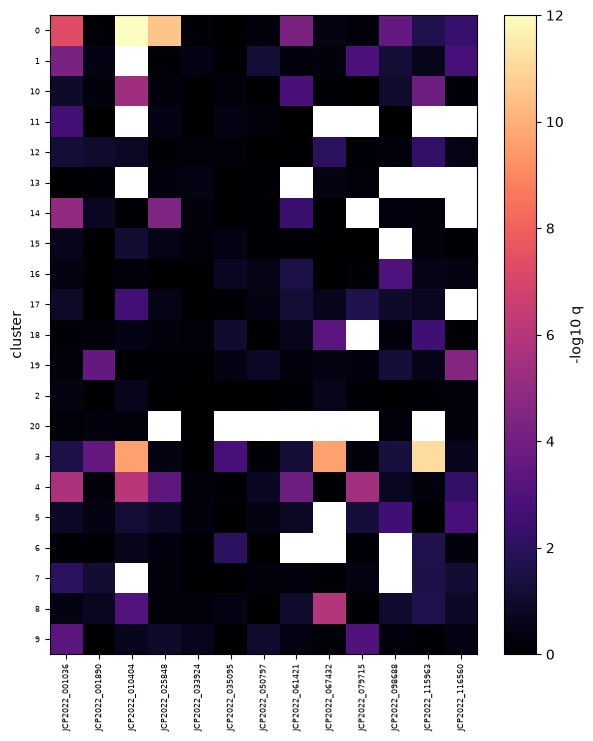

In [10]:
ax = mt.pl.subpopulation_hits(cells)
plt.show()

51 of the 244 tests are significant, spread over eleven of the twelve compounds, so most compounds also shift their
cells within states the controls share.

## Cell cycle

Much of the heterogeneity in a Cell Painting image comes from the cell cycle, so label it before attributing
variation to a treatment. `tl.cell_cycle_phase` fits a two-component mixture to log integrated DNA intensity per
plate. The lower component is G1, the upper is G2M, and cells that neither component claims with confidence are
called S. It needs raw intensities, so it runs on the cells as loaded.

In [11]:
mt.tl.cell_cycle_phase(raw, dna_feature="Nuclei_Intensity_IntegratedIntensity_DNA")
raw.obs["Metadata_CellCyclePhase"].value_counts(normalize=True).round(3).to_dict()

{'G1': 0.549, 'S': 0.297, 'G2M': 0.155}

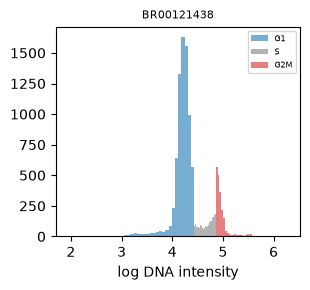

In [12]:
axes = mt.pl.cell_cycle(raw, dna_feature="Nuclei_Intensity_IntegratedIntensity_DNA")
plt.show()

Two peaks, G1 and G2M, with S between them: 55% of the cells are called G1, 30% S and 16% G2M. Check the plot before
using the labels: two separate peaks with the colours split between them means the fit worked, and a single smeared
distribution means it did not, whatever the counts say. This is a heuristic, and it cannot tell G0 from G1.

## Crowding

A cell in a dense field looks different from an isolated one regardless of treatment.
`tl.neighbors_local_density` measures crowding as the mean distance to the *k* nearest cells in the same field of
view, never across fields, from the centroids `read_profiles` keeps on `obs`. `pp.regress_out` then removes it.

In [13]:
mt.tl.neighbors_local_density(raw, k=10)
area = "Cells_AreaShape_Area"


def with_density(adata):
    """How strongly cell area follows crowding, as a correlation."""
    return round(float(np.corrcoef(adata.obs["Metadata_LocalDensity"], np.asarray(adata[:, area].X).ravel())[0, 1]), 3)


before = with_density(raw)
mt.pp.regress_out(raw, keys=["Metadata_LocalDensity"], by="Metadata_Plate")
{"cell area against local density, before": before, "after": with_density(raw)}

{'cell area against local density, before': 0.297, 'after': -0.0}

Isolated cells are larger: cell area follows the mean distance to the ten nearest cells at r = 0.30, and not at all
once the density is regressed out.

## Summary

- Aggregate late. Even the strongest compound here moves about a third of its cells, and a median dilutes that
  by the cells that did not move.
- `method="ks"` and {func}`~mantispy.tl.wasserstein_features` compare whole distributions rather than their
  centres. Cells of one well are not independent, so read a cell-level call as a ranking and put the well-level
  call beside it.
- Composition and within-state testing answer different questions, and an experiment usually needs both.
- Label the cell cycle and measure crowding before attributing variation to a treatment.

Next: [Which measurements moved](../phenotypes/which_features_moved.ipynb).